# DATA 620 Project 2
## Kevin Havis & Aaliyah John-Harry

In [2]:
import nltk
import pandas as pd
import re
from collections import Counter
from nltk.corpus import gutenberg
import matplotlib.pyplot as plt
import numpy as np

## 1. Choose a corpus of interest.

We've chose Jane Austen's *Emma* from the Gutenberg library available in NTLK as our corpus.

> Emma is a novel written by English author Jane Austen. It is set in the fictional Surrey village of Highbury and the surrounding estates of Hartfield, Randalls, and Donwell Abbey, and involves the relationships among people from a small number of families. The novel was first published in December 1815, although the title page is dated 1816. As in her other novels, Austen explores the concerns and difficulties of genteel women living in Georgian–Regency England. Emma is a comedy of manners

[Wikipedia](https://en.wikipedia.org/wiki/Emma_(novel))

In [3]:
words = gutenberg.words("austen-emma.txt")
clean_words = [w.lower() for w in words if re.match("^[a-zA-Z]+$", w)]

## 2. How many total unique words are in the corpus?

We can do this easily with Python's base libraries.

In [4]:
total_words = len(clean_words)
word_counts = Counter(clean_words)
unique_words = len(word_counts)

print("Total words:", total_words)
print("Unique words:", unique_words)

Total words: 161600
Unique words: 7079


## 3. Taking the most common words, how many unique words represent half of the total words in the corpus?

We first sort the words by their frequency, then take the top half and check how many distinct values are in that subset.

In [5]:
sorted_counts = word_counts.most_common()

cumulative = 0
half_total = total_words / 2

num_words_50 = 0

for word, count in sorted_counts:
    cumulative += count
    num_words_50 += 1
    if cumulative >= half_total:
        break

print(
    "Number of unique high-frequency words needed to account for half of the corpus:",
    num_words_50,
)

Number of unique high-frequency words needed to account for half of the corpus: 56


## 4. Identify the 200 highest frequency words in this corpus.

Since we've already sorted the words, we can simply take the top 200 directly, and create a dataframe to further process

In [6]:
top_200 = sorted_counts[:200]

df_top_200 = pd.DataFrame(top_200, columns=["Word", "Frequency"])
df_top_200

,Word,Frequency
0,to,5239
1,the,5201
2,and,4896
3,of,4291
4,i,3178
...,...,...
195,saw,108
196,few,106
197,myself,103
198,till,102


## 5. Create a graph that shows the relative frequency of these 200 words

We have two options for frequency typically with word charts; the typical frequency or bar plot, or word clouds. We chose a bar-style visualization (in this case, a lollipop chart) because it’s easier to read and makes it simple to compare values across words.

In this plot, we’re showing the relative frequency of the top 200 words, which means each word’s count is scaled by the total number of words in the corpus. This makes the results easier to interpret and comparable across different corpora.

As expected, common stop words like “the,” “to,” and “and” dominate the top of the chart. These words appear much more frequently than others, while the rest of the words drop off quickly in frequency. Beyond the stop words, we also begin to see character names and context-specific words from the novel, reflecting Emma's content and writing style.

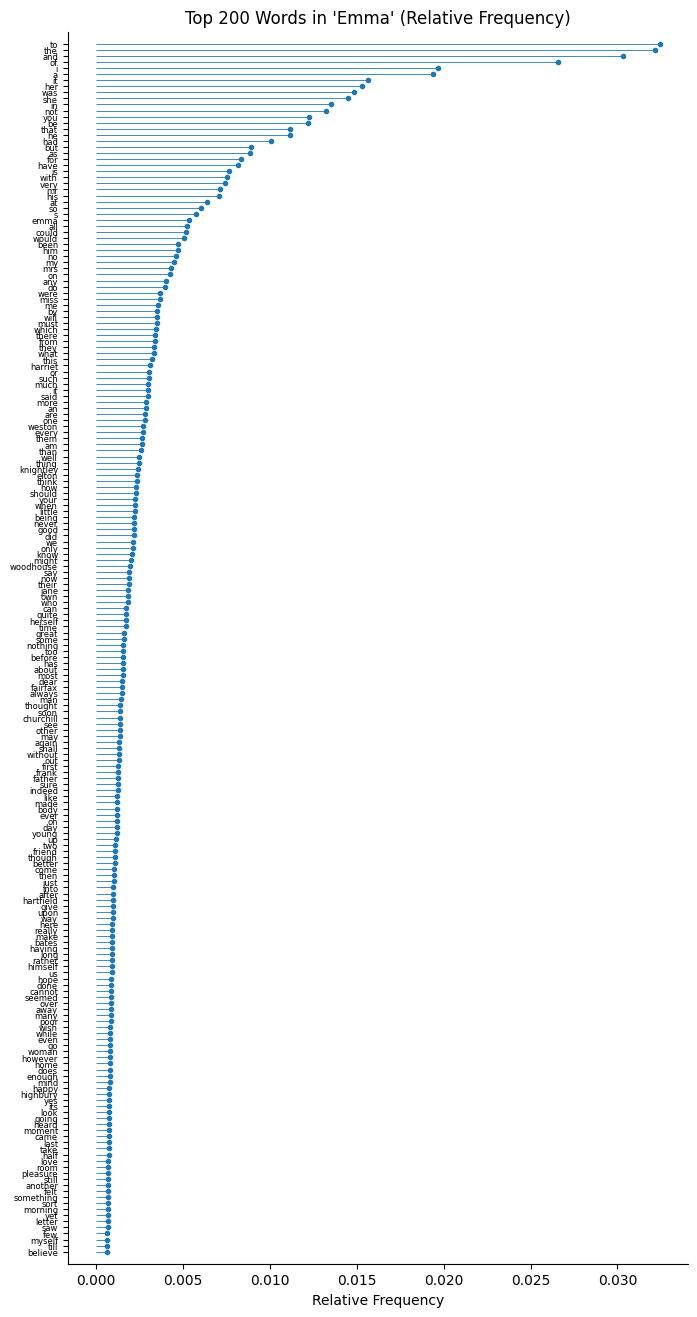

In [10]:
df_top_200["Relative Frequency"] = df_top_200["Frequency"] / total_words
fig, ax = plt.subplots(figsize=(8, 16))

ax.hlines(df_top_200["Word"], 0, df_top_200["Relative Frequency"], linewidth=0.6)
ax.plot(df_top_200["Relative Frequency"], df_top_200["Word"], "o", markersize=3)

ax.tick_params(axis="y", labelsize=6)
ax.invert_yaxis()
ax.set_title("Top 200 Words in 'Emma' (Relative Frequency)")
ax.set_xlabel("Relative Frequency")
ax.margins(y=0.01)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

## 6. Does the observed relative frequency of these words follow Zipf's law?

Zipf's law is essentially a Power Law, stating that when sorted, a series of frequencies is inversely proportional to the rank.

In other words, as rank increases (which is typically represented as decreasing, given we associate rank 1 with being the highest), frequency should decrease at a non-linear rate.

Looking at our plot, we can see that this pattern mostly holds. The highest-ranked words appear much more frequently, and as we move down the ranks, the frequency decreases in a smooth, consistent way. On the log-log plot, this shows up as a roughly straight downward trend, which is what we’d expect if Zipf’s Law is being followed.

That said, it’s not a perfect match. The observed frequencies tend to sit above the Zipf prediction line, especially for lower-frequency words, meaning the decline is a bit slower than the ideal 1/r relationship. So overall, the distribution follows Zipf’s Law pretty well, just not perfectly—which is typical for real-world language data.

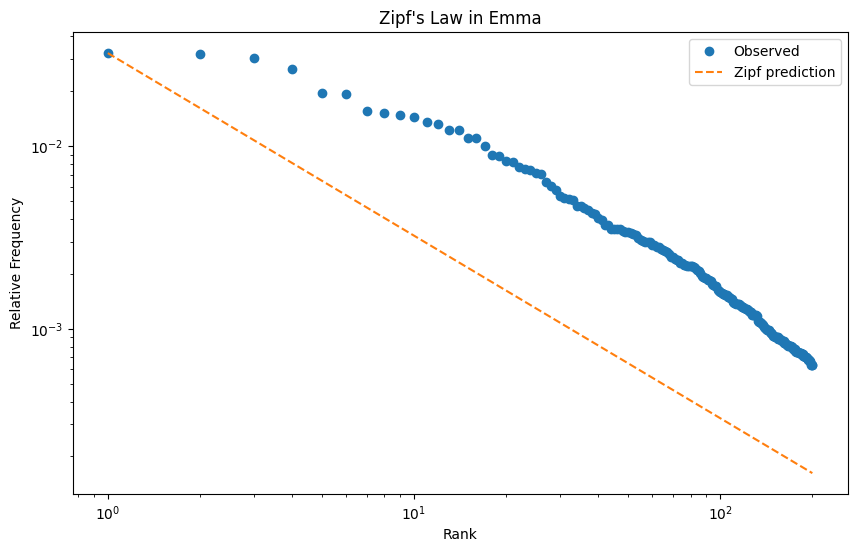

In [12]:
ranks = np.arange(1, len(df_top_200) + 1)
zipf_pred = df_top_200["Relative Frequency"].iloc[0] * (1 / ranks)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, df_top_200["Relative Frequency"], marker="o", linestyle="None", label="Observed")
plt.loglog(ranks, zipf_pred, linestyle="--", label="Zipf prediction")
plt.xlabel("Rank")
plt.ylabel("Relative Frequency")
plt.title("Zipf's Law in Emma")
plt.legend()
plt.show()

## 7. In what ways do you think the frequency of the words in this corpus differs from "all words in all corpora"?

We alluded to the key difference in our corpus earlier; while **stop words** such as `to`, `the`, `and`, `of` will typically be seen in almost every natural language corpus as ranking very high by frequency, the unique elements in a book such as Jane Austen's *Emma* are typically the characters, places, or other nouns.

This holds true in our plots - we see the top words by frequency are all stop words, but the names of main characters such as `emma`, `woodhouse`, and `knightley` still make it into the top 200. We can also see gendered pronouns `she` and `her` being very highly ranked, which gives us the indication that the main character is a woman (if the title didn't give that away already!).

This is why many NLP analyses benefit from the removal of stop words and lemmatization - it allows us to filter through the noise and focus on what's truly unique in the document.